In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib
import json
import warnings

warnings.filterwarnings(
    "ignore",
    message="`sklearn.utils.parallel.delayed` should be used"
)

In [2]:
# Helper functions 

def ks_statistic(y_true, y_score):
    temp = pd.DataFrame({
        "y_true": y_true,
        "y_score": y_score
    }).sort_values("y_score", ascending=False)

    temp["good"] = (temp["y_true"] == 0).astype(int)
    temp["bad"] = (temp["y_true"] == 1).astype(int)

    temp["cum_good"] = temp["good"].cumsum() / temp["good"].sum()
    temp["cum_bad"] = temp["bad"].cumsum() / temp["bad"].sum()

    return (temp["cum_bad"] - temp["cum_good"]).abs().max()


def calculate_classification_diagnostics(
    y_train,
    p_train,
    y_val,
    p_val,
    threshold=0.50
):
    def _metrics(y_true, y_score, dataset_name):
        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        return {
            "dataset": dataset_name,
            "threshold": threshold,
            "auc": roc_auc_score(y_true, y_score),
            "gini": 2 * roc_auc_score(y_true, y_score) - 1,
            "ks": ks_statistic(y_true, y_score),
            "pr_auc": average_precision_score(y_true, y_score),
            "log_loss": log_loss(y_true, y_score),
            "brier_score": brier_score_loss(y_true, y_score),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp
        }

    return pd.DataFrame([
        _metrics(y_train, p_train, "train"),
        _metrics(y_val, p_val, "validation")
    ])

# Generic function to run all tree models and provide predicted probabilities, diagnostics and feature importance 

def get_next_model_number(model_registry, prefix):
    existing_numbers = []

    for model_num in model_registry.keys():
        if model_num.startswith(prefix):
            number_part = model_num.replace(prefix, "")
            if number_part.isdigit():
                existing_numbers.append(int(number_part))

    return max(existing_numbers) + 1 if existing_numbers else 1


def run_tree_model(
    model_registry,
    model,
    model_number,
    model_name,
    X_train,
    X_val,
    y_train,
    y_val,
    features,
    threshold=0.50,
    analyst_comments="",
    run_permutation=True,
    permutation_scoring="roc_auc",
    permutation_repeats=10,
    display_outputs=True
):

    if model_number in model_registry:
        raise ValueError(f"{model_number} already exists.")

    # Store features as a plain list for JSON/config compatibility
    features = list(features)

    model.fit(X_train[features], y_train)

    p_train = model.predict_proba(X_train[features])[:, 1]
    p_val = model.predict_proba(X_val[features])[:, 1]

    diagnostics_table = calculate_classification_diagnostics(
        y_train=y_train,
        p_train=p_train,
        y_val=y_val,
        p_val=p_val,
        threshold=threshold
    )

    if hasattr(model, "feature_importances_"):
        feature_importance_df = pd.DataFrame({
            "variable": features,
            "built_in_importance": model.feature_importances_
        }).sort_values(
            "built_in_importance",
            ascending=False
        ).reset_index(drop=True)
    else:
        feature_importance_df = pd.DataFrame()

    if run_permutation:
        perm_result = permutation_importance(
            model,
            X_val[features],
            y_val,
            scoring=permutation_scoring,
            n_repeats=permutation_repeats,
            random_state=42,
            n_jobs=-1
        )

        permutation_importance_df = pd.DataFrame({
            "variable": features,
            "permutation_importance_mean": perm_result.importances_mean,
            "permutation_importance_std": perm_result.importances_std
        }).sort_values(
            "permutation_importance_mean",
            ascending=False
        ).reset_index(drop=True)
    else:
        permutation_importance_df = pd.DataFrame()

    metadata = {
        "model_number": model_number,
        "model_name": model_name,
        "model_class": type(model).__name__,
        "features": features,
        "num_features": len(features),
        "threshold": threshold,
        "parameters": model.get_params(),
        "analyst_comments": analyst_comments
    }

    model_registry[model_number] = {
        "metadata": metadata,
        "model": model,
        "diagnostics": diagnostics_table,
        "feature_importance": feature_importance_df,
        "permutation_importance": permutation_importance_df,
        "p_train": p_train,
        "p_val": p_val
    }

    if display_outputs:
        print("=" * 100)
        print(f"{model_number}: {model_name}")
        print("=" * 100)

        print("\nMODEL TYPE:")
        print(type(model).__name__)

        print("\nFEATURES:")
        print(features)

        print("\nDIAGNOSTICS:")
        display(diagnostics_table)

        print("\nBUILT-IN FEATURE IMPORTANCE:")
        display(feature_importance_df.head(15))

        print("\nPERMUTATION IMPORTANCE:")
        display(permutation_importance_df.head(15))

        if analyst_comments:
            print("\nANALYST COMMENTS:")
            print(analyst_comments)

    return model_registry

def export_tree_model_registry_to_excel(model_registry, file_path):
    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:

        summary_rows = []

        for model_num, model_data in model_registry.items():
            meta = model_data["metadata"]
            params = meta.get("parameters", {})
            diag = model_data["diagnostics"]

            train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
            val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

            summary_rows.append({
                "model_number": model_num,
                "model_name": meta.get("model_name", ""),
                "model_class": meta.get("model_class", ""),
                "max_depth": params.get("max_depth", ""),
                "min_samples_leaf": params.get("min_samples_leaf", ""),
                "num_features": meta.get("num_features", ""),
                "train_auc": train_row["auc"],
                "val_auc": val_row["auc"],
                "auc_gap": train_row["auc"] - val_row["auc"],
                "train_ks": train_row["ks"],
                "val_ks": val_row["ks"],
                "ks_gap": train_row["ks"] - val_row["ks"],
                "train_pr_auc": train_row["pr_auc"],
                "val_pr_auc": val_row["pr_auc"],
                "train_brier": train_row["brier_score"],
                "val_brier": val_row["brier_score"],
                "train_log_loss": train_row["log_loss"],
                "val_log_loss": val_row["log_loss"],
                "comments": meta.get("analyst_comments", "")
            })

        summary_df = pd.DataFrame(summary_rows).sort_values(
            ["val_auc", "val_ks"],
            ascending=False
        )

        summary_df.to_excel(writer, sheet_name="Summary", index=False)

        for model_num, model_data in model_registry.items():
            sheet_name = model_num[:31]
            start_row = 0

            meta = model_data["metadata"]
            meta_df = pd.DataFrame({
                "field": list(meta.keys()),
                "value": list(meta.values())
            })

            meta_df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
            start_row += len(meta_df) + 3

            model_data["diagnostics"].to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
            start_row += len(model_data["diagnostics"]) + 3

            model_data["feature_importance"].to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)
            start_row += len(model_data["feature_importance"]) + 3

            model_data["permutation_importance"].to_excel(writer, sheet_name=sheet_name, startrow=start_row, index=False)

    print("Saved:", file_path)


def save_model_artifact(model_registry, model_id, model_dir, config_dir):
    record = model_registry[model_id]

    model_path = model_dir / f"{model_id}.joblib"
    config_path = config_dir / f"{model_id}_config.json"

    joblib.dump(record["model"], model_path)

    metadata = record.get("metadata", {}).copy()

    config = {
        "model_id": model_id,
        "model_class": str(type(record["model"]).__name__),
        "metadata": metadata,
        "features": metadata.get("features", None),
        "num_features": metadata.get("num_features", None),
    }

    if "diagnostics" in record:
        try:
            config["diagnostics_preview"] = record["diagnostics"].to_dict(orient="records")
        except Exception:
            pass

    with open(config_path, "w") as f:
        json.dump(config, f, indent=4, default=str)

In [3]:
# Project directory setup

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "saved_models"
CONFIG_DIR = OUTPUT_DIR / "model_configs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs


In [4]:
# Load dataset for tree-based models
df_tree = pd.read_parquet(DATA_DIR / "df_tree_model_ready.parquet")
print(f"Data shape: {df_tree.shape}")
print(df_tree.head())
print(df_tree.dtypes)

Data shape: (149390, 16)
   SeriousDlqin2yrs  age  age_sq  NumberOfTime30-59DaysPastDueNotWorse  \
0                 1   45    2025                                     2   
1                 0   40    1600                                     0   
2                 0   38    1444                                     1   
3                 0   30     900                                     0   
4                 0   49    2401                                     1   

   NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate  \
0                                     0                        0   
1                                     0                        0   
2                                     0                        1   
3                                     0                        0   
4                                     0                        0   

   NumberOfOpenCreditLinesAndLoans  NumberRealEstateLoansOrLines  \
0                               13                   

In [5]:
# target and features and train-validation split
target = "SeriousDlqin2yrs"

candidate_features = [
    col for col in df_tree.columns
    if col != target
]

X = df_tree[candidate_features]
y = df_tree[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Number of candidate features:", len(candidate_features))
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("Train bad rate:", y_train.mean())
print("Validation bad rate:", y_val.mean())

Number of candidate features: 15
X_train: (104573, 15)
X_val: (44817, 15)
Train bad rate: 0.06699626098514913
Validation bad rate: 0.06700582368297744


In [6]:
# Initialize model registry

model_registry = {}

In [7]:
# Run multiple tree models with different depths and min sample leafs

depth_grid = [2, 3, 4, 5, 6, 8, 10]
leaf_grid = [100, 200, 500, 1000]

model_counter = 2

for max_depth in depth_grid:
    for min_samples_leaf in leaf_grid:

        model_number = f"T{model_counter:03d}"

        tree_model = DecisionTreeClassifier(
            criterion="gini",
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

        model_registry = run_tree_model(
            model_registry=model_registry,
            model=tree_model,
            model_number=model_number,
            model_name=f"Decision Tree - depth {max_depth}, leaf {min_samples_leaf}",
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            features=candidate_features,
            analyst_comments=(
                f"Decision tree tuning run with max_depth={max_depth} "
                f"and min_samples_leaf={min_samples_leaf}."
            ),
            run_permutation=True,
            permutation_repeats=5,
            display_outputs=False
        )

        model_counter += 1

print(f"Registered {len(model_registry)} tree models.")

Registered 28 tree models.


In [9]:
# Display diagnostics summaries for the models run:

summary_rows = []

for model_num, model_data in model_registry.items():

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "max_depth": params.get("max_depth"),
        "min_samples_leaf": params.get("min_samples_leaf"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "train_pr_auc": train_row["pr_auc"],
        "val_pr_auc": val_row["pr_auc"],
        "train_brier": train_row["brier_score"],
        "val_brier": val_row["brier_score"],
        "train_log_loss": train_row["log_loss"],
        "val_log_loss": val_row["log_loss"]
    })

tree_tuning_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(tree_tuning_summary)

,model_number,model_name,max_depth,min_samples_leaf,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,train_pr_auc,val_pr_auc,train_brier,val_brier,train_log_loss,val_log_loss
0,T028,"Decision Tree - depth 10, leaf 500",10,500,0.863726,0.854919,0.008807,0.569911,0.564483,0.005428,0.373950,0.363612,0.049710,0.050207,0.179270,0.182366
1,T022,"Decision Tree - depth 8, leaf 100",8,100,0.862440,0.854637,0.007803,0.566637,0.565238,0.001398,0.400507,0.377152,0.048819,0.049966,0.177667,0.181777
2,T024,"Decision Tree - depth 8, leaf 500",8,500,0.859545,0.854468,0.005077,0.563599,0.558312,0.005287,0.370829,0.362107,0.049781,0.050198,0.180315,0.182158
3,T029,"Decision Tree - depth 10, leaf 1000",10,1000,0.861311,0.854365,0.006946,0.570255,0.570280,-0.000026,0.358986,0.355494,0.050102,0.050412,0.180599,0.182878
4,T023,"Decision Tree - depth 8, leaf 200",8,200,0.861322,0.854324,0.006998,0.564083,0.561140,0.002943,0.390519,0.372949,0.049172,0.049989,0.178633,0.181939
5,T025,"Decision Tree - depth 8, leaf 1000",8,1000,0.857925,0.853981,0.003944,0.565683,0.569740,-0.004057,0.356672,0.353974,0.050157,0.050422,0.181442,0.182800
6,T027,"Decision Tree - depth 10, leaf 200",10,200,0.868264,0.853804,0.014460,0.579420,0.555151,0.024269,0.397298,0.373654,0.048901,0.050058,0.176492,0.185720
7,T026,"Decision Tree - depth 10, leaf 100",10,100,0.871041,0.852154,0.018887,0.583709,0.563101,0.020608,0.411663,0.374825,0.048356,0.050211,0.174664,0.192542
8,T018,"Decision Tree - depth 6, leaf 100",6,100,0.849864,0.848428,0.001436,0.555581,0.564662,-0.009081,0.379098,0.367500,0.049435,0.049847,0.180980,0.182080
9,T019,"Decision Tree - depth 6, leaf 200",6,200,0.849556,0.847684,0.001872,0.555775,0.565392,-0.009618,0.375655,0.364478,0.049565,0.050018,0.181304,0.182605


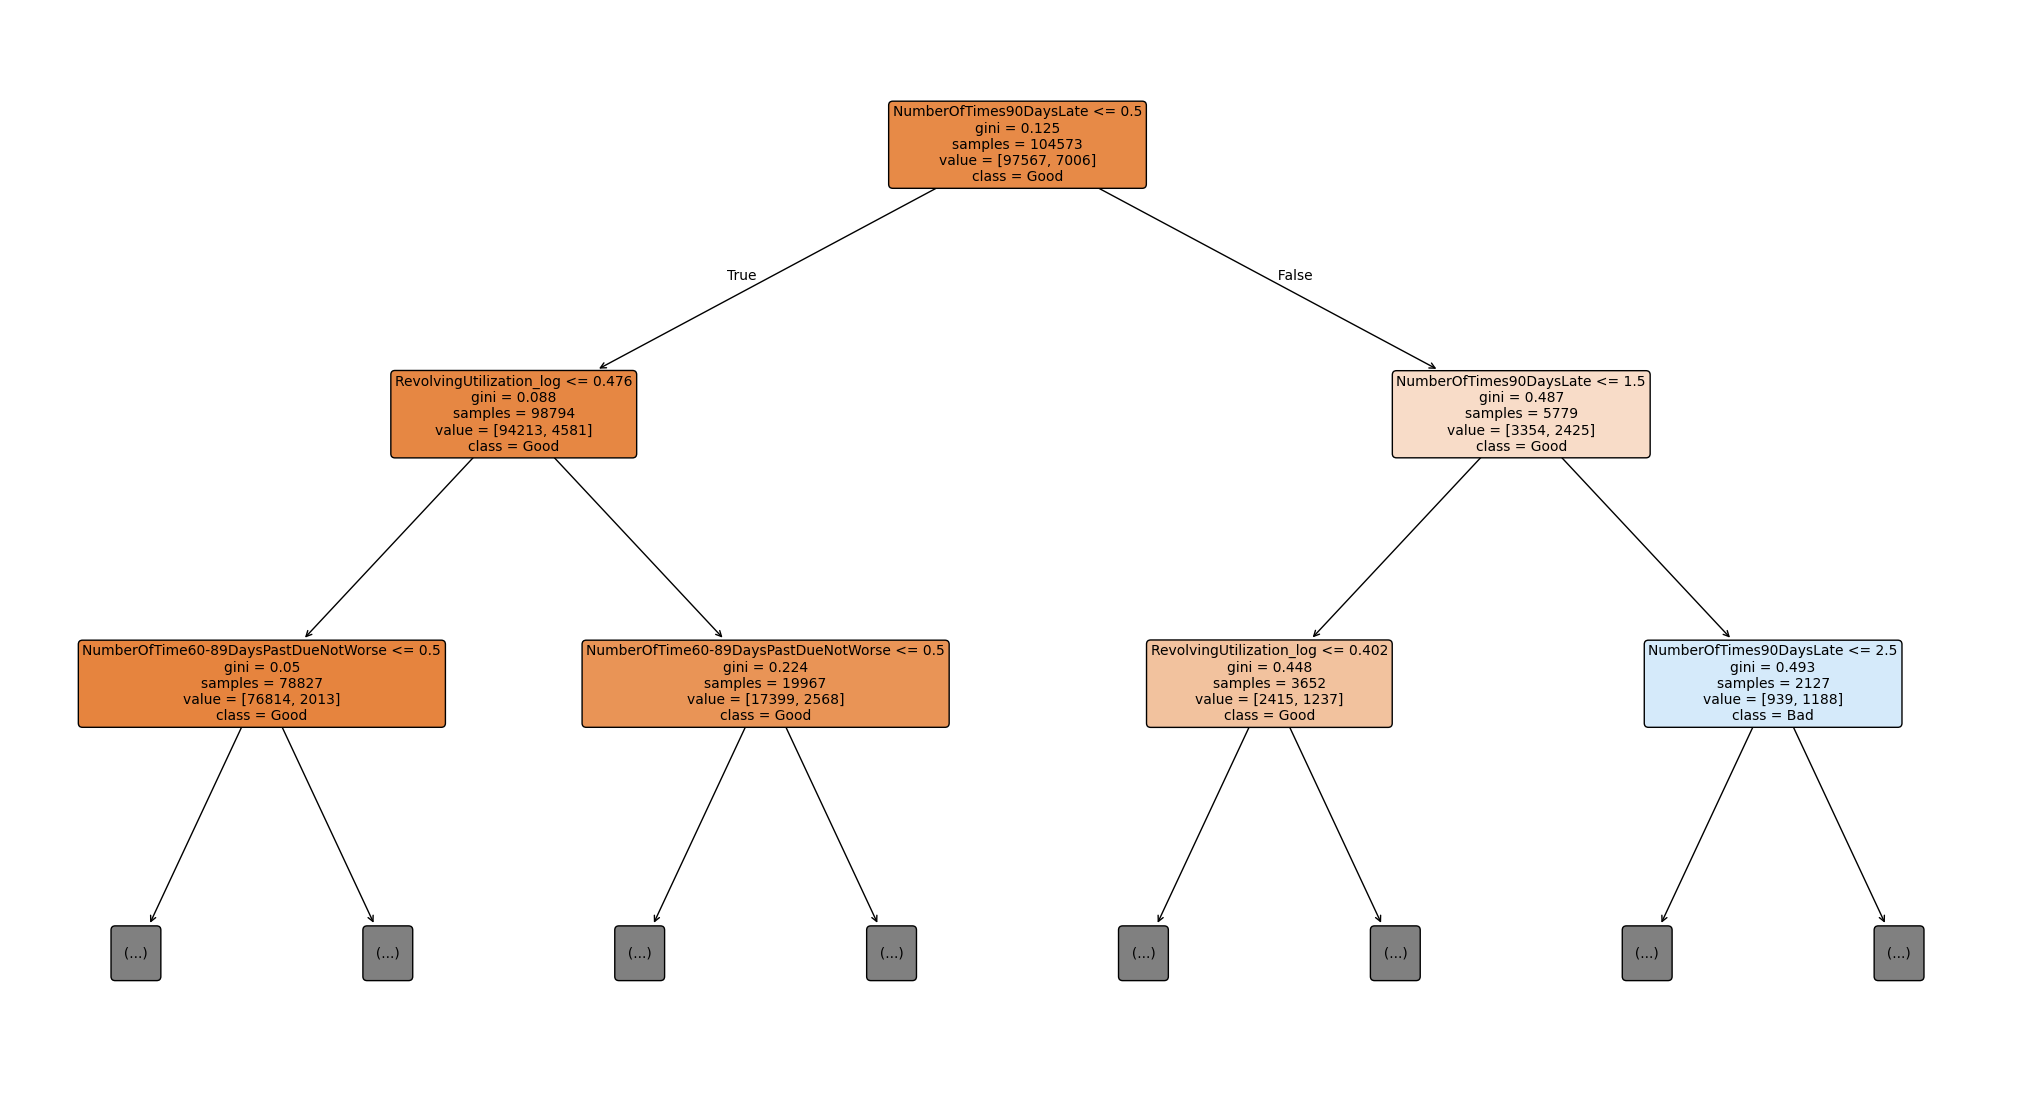

In [11]:
# Visualize the tree

plt.figure(figsize=(26,14))

plot_tree(
    tree_model,
    feature_names=candidate_features,
    class_names=["Good", "Bad"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)

plt.show()

In [12]:
# Compare Top 3 Tree Models Importance

top_models = ["T024", "T028", "T029"]

for model_id in top_models:

    print("=" * 100)
    print(model_id, "-", model_registry[model_id]["metadata"]["model_name"])
    print("=" * 100)

    print("\nBUILT-IN IMPORTANCE")
    display(
        model_registry[model_id]["feature_importance"].head(10)
    )

    print("\nPERMUTATION IMPORTANCE")
    display(
        model_registry[model_id]["permutation_importance"].head(10)
    )

T024 - Decision Tree - depth 8, leaf 500

BUILT-IN IMPORTANCE


,variable,built_in_importance
0,NumberOfTimes90DaysLate,0.620336
1,RevolvingUtilization_log,0.164350
2,NumberOfTime60-89DaysPastDueNotWorse,0.103129
3,NumberOfTime30-59DaysPastDueNotWorse,0.082099
4,DebtRatio_log,0.014828
5,age_sq,0.003847
6,NumberOfOpenCreditLinesAndLoans,0.003618
7,age,0.002525
8,NumberRealEstateLoansOrLines,0.002510
9,MonthlyIncome_median,0.001407



PERMUTATION IMPORTANCE


,variable,permutation_importance_mean,permutation_importance_std
0,RevolvingUtilization_log,0.065455,0.001828
1,NumberOfTimes90DaysLate,0.043150,0.001342
2,NumberOfTime30-59DaysPastDueNotWorse,0.036319,0.001402
3,NumberOfTime60-89DaysPastDueNotWorse,0.016985,0.001232
4,age,0.005442,0.000812
5,age_sq,0.004143,0.000462
6,NumberOfOpenCreditLinesAndLoans,0.004071,0.000643
7,DebtRatio_log,0.003614,0.000405
8,NumberRealEstateLoansOrLines,0.001477,0.000228
9,DebtRatio_high_flag,0.000483,0.000102


T028 - Decision Tree - depth 10, leaf 500

BUILT-IN IMPORTANCE


...

,variable,permutation_importance_mean,permutation_importance_std
0,RevolvingUtilization_log,0.067198,0.002582
1,NumberOfTimes90DaysLate,0.044005,0.001404
2,NumberOfTime30-59DaysPastDueNotWorse,0.034019,0.001198
3,NumberOfTime60-89DaysPastDueNotWorse,0.017275,0.001129
4,age,0.004829,0.000920
5,age_sq,0.003786,0.000436
6,NumberOfOpenCreditLinesAndLoans,0.003705,0.000462
7,DebtRatio_log,0.003654,0.000427
8,NumberRealEstateLoansOrLines,0.001474,0.000276
9,MonthlyIncome_median,0.000597,0.000397


T029 - Decision Tree - depth 10, leaf 1000

BUILT-IN IMPORTANCE


,variable,built_in_importance
0,NumberOfTimes90DaysLate,0.640400
1,RevolvingUtilization_log,0.169888
2,NumberOfTime60-89DaysPastDueNotWorse,0.094448
3,NumberOfTime30-59DaysPastDueNotWorse,0.075919
4,DebtRatio_log,0.005749
5,age_sq,0.004203
6,NumberOfOpenCreditLinesAndLoans,0.003859
7,NumberRealEstateLoansOrLines,0.003150
8,age,0.002185
9,MonthlyIncome_median,0.000200



PERMUTATION IMPORTANCE


,variable,permutation_importance_mean,permutation_importance_std
0,RevolvingUtilization_log,0.069049,0.002536
1,NumberOfTimes90DaysLate,0.043027,0.001174
2,NumberOfTime30-59DaysPastDueNotWorse,0.037234,0.001172
3,NumberOfTime60-89DaysPastDueNotWorse,0.020014,0.001187
4,age,0.003950,0.001094
5,age_sq,0.003109,0.000370
6,NumberOfOpenCreditLinesAndLoans,0.002965,0.000562
7,NumberRealEstateLoansOrLines,0.002741,0.000349
8,DebtRatio_log,0.001149,0.000217
9,MonthlyIncome_median,0.000090,0.000253


In [13]:
# Download model registry as excel
tree_registry_path = OUTPUT_DIR / "tree_model_registry.xlsx"

export_tree_model_registry_to_excel(
    model_registry=model_registry,
    file_path=tree_registry_path
)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/tree_model_registry.xlsx


In [14]:
# Download champion model (T024) with full diagnostics

champion_tree_number = "T024"
champion_tree = model_registry[champion_tree_number]

champion_tree_path = OUTPUT_DIR / f"{champion_tree_number}_champion_tree_diagnostics.xlsx"

with pd.ExcelWriter(champion_tree_path, engine="openpyxl") as writer:

    pd.DataFrame({
        "field": list(champion_tree["metadata"].keys()),
        "value": list(champion_tree["metadata"].values())
    }).to_excel(writer, sheet_name="Metadata", index=False)

    champion_tree["diagnostics"].to_excel(writer, sheet_name="Diagnostics", index=False)
    champion_tree["feature_importance"].to_excel(writer, sheet_name="BuiltIn_Importance", index=False)
    champion_tree["permutation_importance"].to_excel(writer, sheet_name="Permutation_Importance", index=False)

print("Saved:", champion_tree_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/T024_champion_tree_diagnostics.xlsx


## Champion Single Decision Tree

T024 was selected as the champion single decision tree because it produced near-best validation AUC while using a simpler structure than the deepest alternatives.

Although T028 had a slightly higher validation AUC, the improvement was minimal. T024 was preferred because it used lower depth, had a smaller train-validation gap, and offered a better balance between performance, stability, and interpretability.

# Random Forest Models

In [8]:
# Random Forest model inputs grid

rf_grid = [
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 250,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 1000, "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": 0.5,    "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": None,   "class_weight": None},
    {"n_estimators": 500, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": "balanced"},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 250,  "max_features": "sqrt", "class_weight": "balanced"},
]


In [9]:
# Run Random Forest models

grid_to_run = rf_grid   # or rf_grid_additional_01 later

start_num = get_next_model_number(model_registry, "RF")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"RF{i:03d}"

    rf_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        criterion="gini",
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=rf_model,
        model_number=model_number,
        model_name=(
            "Random Forest - "
            f"trees {params['n_estimators']}, "
            f"depth {params['max_depth']}, "
            f"leaf {params['min_samples_leaf']}, "
            f"max_features {params['max_features']}, "
            f"class_weight {params['class_weight']}"
        ),
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments=(
            "Random Forest tuning run. "
            f"Parameters: {params}"
        ),
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

print("Random Forest grid complete.")

Random Forest grid complete.


In [21]:
# Summary tables for all random forest models run

rf_summary_rows = []

for model_num, model_data in model_registry.items():

    if not model_num.startswith("RF"):
        continue

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    rf_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "n_estimators": params.get("n_estimators"),
        "max_depth": params.get("max_depth"),
        "min_samples_leaf": params.get("min_samples_leaf"),
        "max_features": params.get("max_features"),
        "class_weight": params.get("class_weight"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "train_pr_auc": train_row["pr_auc"],
        "val_pr_auc": val_row["pr_auc"],
        "train_brier": train_row["brier_score"],
        "val_brier": val_row["brier_score"],
        "train_log_loss": train_row["log_loss"],
        "val_log_loss": val_row["log_loss"]
    })

rf_summary_df = (
    pd.DataFrame(rf_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(rf_summary_df)

,model_number,model_name,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,train_pr_auc,val_pr_auc,train_brier,val_brier,train_log_loss,val_log_loss
0,RF002,"Random Forest - trees 300, depth 10, leaf 500,...",300,10,500,sqrt,NaN,0.866373,0.863409,0.002964,0.571349,0.576284,-0.004935,0.386850,0.390335,0.050463,0.050485,0.181956,0.182483
1,RF003,"Random Forest - trees 300, depth 8, leaf 250, ...",300,8,250,sqrt,NaN,0.866448,0.863200,0.003249,0.572876,0.576080,-0.003203,0.395248,0.393780,0.049898,0.050006,0.180602,0.181298
2,RF009,"Random Forest - trees 300, depth 10, leaf 250,...",300,10,250,sqrt,balanced,0.869503,0.862928,0.006575,0.577390,0.575037,0.002354,0.390082,0.384114,0.146701,0.147469,0.457986,0.460149
3,RF001,"Random Forest - trees 300, depth 8, leaf 500, ...",300,8,500,sqrt,NaN,0.864724,0.862695,0.002029,0.568434,0.574842,-0.006409,0.386777,0.390277,0.050490,0.050484,0.182611,0.182841
4,RF007,"Random Forest - trees 500, depth 8, leaf 500, ...",500,8,500,sqrt,NaN,0.864669,0.862675,0.001994,0.569213,0.574472,-0.005259,0.387150,0.390653,0.050468,0.050458,0.182543,0.182765
5,RF005,"Random Forest - trees 300, depth 8, leaf 500, ...",300,8,500,0.5,NaN,0.864551,0.862279,0.002271,0.571162,0.577582,-0.006420,0.390054,0.391262,0.049709,0.049759,0.179494,0.180035
6,RF004,"Random Forest - trees 300, depth 8, leaf 1000,...",300,8,1000,sqrt,NaN,0.862383,0.860909,0.001474,0.564498,0.571580,-0.007082,0.378334,0.383539,0.051441,0.051400,0.186036,0.186086
7,RF006,"Random Forest - trees 300, depth 8, leaf 500, ...",300,8,500,None,NaN,0.863842,0.860553,0.003289,0.570424,0.575124,-0.004700,0.387686,0.385354,0.049720,0.049941,0.179557,0.180696
8,RF008,"Random Forest - trees 300, depth 8, leaf 500, ...",300,8,500,sqrt,balanced,0.861578,0.859417,0.002162,0.560226,0.566315,-0.006090,0.374463,0.373441,0.153039,0.153189,0.475420,0.476038


In [22]:
# Inspect importance scores of the champion random forest models

rf_champion_id = "RF002"

print(model_registry[rf_champion_id]["metadata"]["model_name"])

print("\nBUILT-IN IMPORTANCE")
display(model_registry[rf_champion_id]["feature_importance"].head(15))

print("\nPERMUTATION IMPORTANCE")
display(model_registry[rf_champion_id]["permutation_importance"].head(15))

Random Forest - trees 300, depth 10, leaf 500, max_features sqrt, class_weight None

BUILT-IN IMPORTANCE


,variable,built_in_importance
0,NumberOfTimes90DaysLate,0.347865
1,RevolvingUtilization_log,0.217664
2,NumberOfTime60-89DaysPastDueNotWorse,0.181376
3,NumberOfTime30-59DaysPastDueNotWorse,0.161370
4,age,0.022078
5,age_sq,0.020735
6,NumberOfOpenCreditLinesAndLoans,0.018788
7,DebtRatio_log,0.011118
8,MonthlyIncome_median,0.007670
9,NumberRealEstateLoansOrLines,0.007629



PERMUTATION IMPORTANCE


,variable,permutation_importance_mean,permutation_importance_std
0,RevolvingUtilization_log,0.055535,0.001688
1,NumberOfTimes90DaysLate,0.036090,0.001164
2,NumberOfTime30-59DaysPastDueNotWorse,0.033871,0.000881
3,NumberOfTime60-89DaysPastDueNotWorse,0.017458,0.001229
4,DebtRatio_log,0.003761,0.000328
5,NumberOfOpenCreditLinesAndLoans,0.002541,0.000190
6,age,0.001922,0.000464
7,NumberRealEstateLoansOrLines,0.001740,0.000189
8,MonthlyIncome_median,0.001277,0.000136
9,age_sq,0.001248,0.000370


# Extra Trees Models

In [10]:
# Extra trees models grid

et_grid = [
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 250,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 1000, "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": 0.5,    "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": None,   "class_weight": None},
    {"n_estimators": 500, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 300, "max_depth": 8,  "min_samples_leaf": 500,  "max_features": "sqrt", "class_weight": "balanced"},
    {"n_estimators": 300, "max_depth": 10, "min_samples_leaf": 250,  "max_features": "sqrt", "class_weight": "balanced"},
]

In [26]:
# Remove existing ET models before rerunning ET grid
for key in list(model_registry.keys()):
    if key.startswith("ET"):
        del model_registry[key]

print("Existing ET models removed.")

Existing ET models removed.


In [11]:
# Run ET models

grid_to_run = et_grid  # or et_grid_additional_01 later

start_num = get_next_model_number(model_registry, "ET")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"ET{i:03d}"

    et_model = ExtraTreesClassifier(
        n_estimators=params["n_estimators"],
        criterion="gini",
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=et_model,
        model_number=model_number,
        model_name=(
            "Extra Trees - "
            f"trees {params['n_estimators']}, "
            f"depth {params['max_depth']}, "
            f"leaf {params['min_samples_leaf']}, "
            f"max_features {params['max_features']}, "
            f"class_weight {params['class_weight']}"
        ),
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments=(
            "Extra Trees tuning run. "
            f"Parameters: {params}"
        ),
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

print("Extra Trees grid complete.")

Extra Trees grid complete.


In [28]:
# Extra Trees summary tables

et_summary_rows = []
for model_num, model_data in model_registry.items():
    if not model_num.startswith("ET"):
        continue
    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]
    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]
    et_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "n_estimators": params.get("n_estimators"),
        "max_depth": params.get("max_depth"),
        "min_samples_leaf": params.get("min_samples_leaf"),
        "max_features": params.get("max_features"),
        "class_weight": params.get("class_weight"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "train_pr_auc": train_row["pr_auc"],
        "val_pr_auc": val_row["pr_auc"],
        "train_brier": train_row["brier_score"],
        "val_brier": val_row["brier_score"],
        "train_log_loss": train_row["log_loss"],
        "val_log_loss": val_row["log_loss"]
    })
et_summary_df = (
    pd.DataFrame(et_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)
display(et_summary_df)

,model_number,model_name,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,train_pr_auc,val_pr_auc,train_brier,val_brier,train_log_loss,val_log_loss
0,ET006,"Extra Trees - trees 300, depth 8, leaf 500, ma...",300,8,500,None,NaN,0.851699,0.851205,0.000494,0.546688,0.549571,-0.002882,0.359648,0.361588,0.052878,0.052818,0.189958,0.189884
1,ET005,"Extra Trees - trees 300, depth 8, leaf 500, ma...",300,8,500,0.5,NaN,0.840075,0.839117,0.000958,0.524171,0.523927,0.000244,0.338017,0.336761,0.055092,0.055115,0.199427,0.199603
2,ET003,"Extra Trees - trees 300, depth 8, leaf 250, ma...",300,8,250,sqrt,NaN,0.830466,0.829731,0.000735,0.509944,0.516231,-0.006287,0.316050,0.316110,0.057949,0.057980,0.215532,0.215676
3,ET002,"Extra Trees - trees 300, depth 10, leaf 500, m...",300,10,500,sqrt,NaN,0.822418,0.821403,0.001014,0.499430,0.505360,-0.005930,0.305238,0.305573,0.058900,0.058929,0.220889,0.221036
4,ET007,"Extra Trees - trees 500, depth 8, leaf 500, ma...",500,8,500,sqrt,NaN,0.821727,0.820597,0.001129,0.496911,0.501533,-0.004622,0.301438,0.303467,0.058950,0.058977,0.221185,0.221338
5,ET001,"Extra Trees - trees 300, depth 8, leaf 500, ma...",300,8,500,sqrt,NaN,0.821135,0.819933,0.001202,0.498936,0.502870,-0.003934,0.302255,0.301729,0.058988,0.059019,0.221388,0.221557
6,ET004,"Extra Trees - trees 300, depth 8, leaf 1000, m...",300,8,1000,sqrt,NaN,0.818958,0.818279,0.000679,0.489749,0.493412,-0.003662,0.304322,0.305693,0.059444,0.059463,0.224138,0.224246
7,ET009,"Extra Trees - trees 300, depth 10, leaf 250, m...",300,10,250,sqrt,balanced,0.817382,0.815043,0.002339,0.490025,0.491454,-0.001429,0.281373,0.282751,0.200705,0.200870,0.591465,0.591783
8,ET008,"Extra Trees - trees 300, depth 8, leaf 500, ma...",300,8,500,sqrt,balanced,0.808592,0.806496,0.002096,0.480474,0.478091,0.002382,0.263897,0.266427,0.209591,0.209725,0.610464,0.610723


Extra Trees models underperformed the Random Forest champion. The strongest Extra Trees run used all features at each split, suggesting that excessive randomization weakened performance because a small number of dominant predictors carried substantial signal.

# GB/HistGradientBoosting

In [13]:
# Gradient Boosting Grid

gb_grid = [
    {"max_iter": 200, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 500, "l2_regularization": 0.0},
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 500, "l2_regularization": 0.0},
    {"max_iter": 200, "learning_rate": 0.10, "max_depth": 3, "min_samples_leaf": 500, "l2_regularization": 0.0},
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 5, "min_samples_leaf": 250, "l2_regularization": 0.0},
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 5, "min_samples_leaf": 500, "l2_regularization": 1.0},
]

gb_grid_additional_01 = [
    # Stronger regularization
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 5, "min_samples_leaf": 500, "l2_regularization": 2.0},
    # Slightly shallower = simpler challenger
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 4, "min_samples_leaf": 500, "l2_regularization": 1.0},
    # Slower learning / more trees
    {"max_iter": 500, "learning_rate": 0.03, "max_depth": 5, "min_samples_leaf": 500, "l2_regularization": 1.0},
    # Larger leaf = smoother
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 5, "min_samples_leaf": 750, "l2_regularization": 1.0},
    # Slightly more aggressive learning
    {"max_iter": 200, "learning_rate": 0.07, "max_depth": 5, "min_samples_leaf": 500, "l2_regularization": 1.0
    }

]

In [15]:
# Choose grid to run
grid_to_run = gb_grid_additional_01

start_num = get_next_model_number(model_registry, "GB")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"GB{i:03d}"

    gb_model = HistGradientBoostingClassifier(
        max_iter=params["max_iter"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        random_state=42
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=gb_model,
        model_number=model_number,
        model_name=f"HistGradientBoosting {params}",
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments="GB run",
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

In [38]:
# GB summary table

gb_summary_rows = []

for model_num, model_data in model_registry.items():

    if not model_num.startswith("GB"):
        continue

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    gb_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "max_iter": params.get("max_iter"),
        "learning_rate": params.get("learning_rate"),
        "max_depth": params.get("max_depth"),
        "min_samples_leaf": params.get("min_samples_leaf"),
        "l2_regularization": params.get("l2_regularization"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "val_pr_auc": val_row["pr_auc"],
        "val_brier": val_row["brier_score"],
        "val_log_loss": val_row["log_loss"]
    })

gb_summary_df = (
    pd.DataFrame(gb_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(gb_summary_df)

,model_number,model_name,max_iter,learning_rate,max_depth,min_samples_leaf,l2_regularization,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,val_pr_auc,val_brier,val_log_loss
0,GB008,"HistGradientBoosting {'max_iter': 500, 'learni...",500,0.03,5,500,1.0,0.875048,0.867354,0.007694,0.590395,0.583597,0.006797,0.411078,0.048738,0.176564
1,GB005,"HistGradientBoosting - iter 300, lr 0.05, dept...",300,0.05,5,500,1.0,0.874312,0.867336,0.006976,0.587471,0.584287,0.003184,0.410896,0.048745,0.176591
2,GB006,"HistGradientBoosting {'max_iter': 300, 'learni...",300,0.05,5,500,2.0,0.874535,0.867310,0.007225,0.588618,0.583788,0.004830,0.410623,0.048760,0.176622
3,GB004,"HistGradientBoosting - iter 300, lr 0.05, dept...",300,0.05,5,250,0.0,0.872881,0.867237,0.005645,0.585718,0.585550,0.000168,0.410408,0.048729,0.176682
4,GB007,"HistGradientBoosting {'max_iter': 300, 'learni...",300,0.05,4,500,1.0,0.871341,0.867080,0.004261,0.583507,0.586178,-0.002671,0.412001,0.048718,0.176621
5,GB010,"HistGradientBoosting {'max_iter': 200, 'learni...",200,0.07,5,500,1.0,0.876637,0.866980,0.009656,0.592717,0.581988,0.010730,0.409770,0.048778,0.176703
6,GB009,"HistGradientBoosting {'max_iter': 300, 'learni...",300,0.05,5,750,1.0,0.873443,0.866878,0.006565,0.586044,0.583448,0.002596,0.410207,0.048785,0.176789
7,GB003,"HistGradientBoosting - iter 200, lr 0.1, depth...",200,0.10,3,500,0.0,0.868601,0.866366,0.002235,0.576977,0.581799,-0.004822,0.411636,0.048738,0.176891
8,GB001,"HistGradientBoosting - iter 200, lr 0.05, dept...",200,0.05,3,500,0.0,0.868055,0.866341,0.001714,0.577270,0.580409,-0.003138,0.411232,0.048738,0.176946
9,GB002,"HistGradientBoosting - iter 300, lr 0.05, dept...",300,0.05,3,500,0.0,0.868055,0.866341,0.001714,0.577270,0.580409,-0.003138,0.411232,0.048738,0.176946


# XGBoost

In [16]:
# XGBoost Model Grid

xgb_grid = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3, "min_child_weight": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "min_child_weight": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4, "min_child_weight": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "min_child_weight": 250, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "min_child_weight": 500, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 2.0},
]

In [17]:
# Run XGBoost Grid

grid_to_run = xgb_grid
start_num = get_next_model_number(model_registry, "XGB")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"XGB{i:03d}"

    xgb_model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_lambda=params["reg_lambda"],
        random_state=42,
        n_jobs=-1
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=xgb_model,
        model_number=model_number,
        model_name=f"XGBoost {params}",
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments=f"XGBoost tuning run: {params}",
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

print("XGBoost grid complete.")

XGBoost grid complete.


In [ ]:
# XGBoost summary tables

xgb_summary_rows = []

for model_num, model_data in model_registry.items():

    if not model_num.startswith("XGB"):
        continue

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    xgb_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "n_estimators": params.get("n_estimators"),
        "learning_rate": params.get("learning_rate"),
        "max_depth": params.get("max_depth"),
        "min_child_weight": params.get("min_child_weight"),
        "subsample": params.get("subsample"),
        "colsample_bytree": params.get("colsample_bytree"),
        "reg_lambda": params.get("reg_lambda"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "val_pr_auc": val_row["pr_auc"],
        "val_brier": val_row["brier_score"],
        "val_log_loss": val_row["log_loss"]
    })

xgb_summary_df = (
    pd.DataFrame(xgb_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(xgb_summary_df)

# LightGBM

In [18]:
# LightGBM Model Grid

lgb_grid = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3, "num_leaves": 15, "min_child_samples": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "num_leaves": 31, "min_child_samples": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4, "num_leaves": 31, "min_child_samples": 500, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "num_leaves": 15, "min_child_samples": 250, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5, "num_leaves": 31, "min_child_samples": 500, "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 2.0},
]

In [19]:
# Run LightGBM Grid

grid_to_run = lgb_grid
start_num = get_next_model_number(model_registry, "LGB")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"LGB{i:03d}"

    lgb_model = lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_lambda=params["reg_lambda"],
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=lgb_model,
        model_number=model_number,
        model_name=f"LightGBM {params}",
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments=f"LightGBM tuning run: {params}",
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

print("LightGBM grid complete.")

LightGBM grid complete.


In [29]:
# LightGBM Summary

lgb_summary_rows = []

for model_num, model_data in model_registry.items():

    if not model_num.startswith("LGB"):
        continue

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    lgb_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "n_estimators": params.get("n_estimators"),
        "learning_rate": params.get("learning_rate"),
        "max_depth": params.get("max_depth"),
        "num_leaves": params.get("num_leaves"),
        "min_child_samples": params.get("min_child_samples"),
        "subsample": params.get("subsample"),
        "colsample_bytree": params.get("colsample_bytree"),
        "reg_lambda": params.get("reg_lambda"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "val_pr_auc": val_row["pr_auc"],
        "val_brier": val_row["brier_score"],
        "val_log_loss": val_row["log_loss"]
    })

lgb_summary_df = (
    pd.DataFrame(lgb_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(lgb_summary_df)

,model_number,model_name,n_estimators,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,val_pr_auc,val_brier,val_log_loss
0,LGB002,"LightGBM {'n_estimators': 300, 'learning_rate'...",300,0.05,4,31,500,0.8,0.8,1.0,0.874775,0.868180,0.006595,0.590303,0.585756,0.004547,0.412751,0.048625,0.176125
1,LGB004,"LightGBM {'n_estimators': 300, 'learning_rate'...",300,0.05,4,15,250,0.8,0.8,1.0,0.875745,0.867964,0.007781,0.592272,0.588383,0.003889,0.412863,0.048624,0.176190
2,LGB003,"LightGBM {'n_estimators': 500, 'learning_rate'...",500,0.03,4,31,500,0.8,0.8,1.0,0.874968,0.867918,0.007050,0.590317,0.585083,0.005234,0.412870,0.048613,0.176148
3,LGB001,"LightGBM {'n_estimators': 300, 'learning_rate'...",300,0.05,3,15,500,0.8,0.8,1.0,0.870303,0.867840,0.002464,0.581646,0.584744,-0.003098,0.415088,0.048573,0.176165
4,LGB005,"LightGBM {'n_estimators': 300, 'learning_rate'...",300,0.05,5,31,500,0.9,0.9,2.0,0.879401,0.867234,0.012167,0.595208,0.584334,0.010874,0.411899,0.048698,0.176473


# CatBoost

In [20]:
# CatBoost Model Grid

cat_grid = [
    {"iterations": 300, "learning_rate": 0.05, "depth": 3, "l2_leaf_reg": 3.0},
    {"iterations": 300, "learning_rate": 0.05, "depth": 4, "l2_leaf_reg": 3.0},
    {"iterations": 500, "learning_rate": 0.03, "depth": 4, "l2_leaf_reg": 3.0},
    {"iterations": 300, "learning_rate": 0.05, "depth": 4, "l2_leaf_reg": 5.0},
    {"iterations": 300, "learning_rate": 0.05, "depth": 5, "l2_leaf_reg": 5.0},
]

In [21]:
# Run CatBoost Grid

grid_to_run = cat_grid
start_num = get_next_model_number(model_registry, "CAT")

for i, params in enumerate(grid_to_run, start=start_num):

    model_number = f"CAT{i:03d}"

    cat_model = CatBoostClassifier(
        iterations=params["iterations"],
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        allow_writing_files=False,
        verbose=False
    )

    model_registry = run_tree_model(
        model_registry=model_registry,
        model=cat_model,
        model_number=model_number,
        model_name=f"CatBoost {params}",
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        features=candidate_features,
        analyst_comments=f"CatBoost tuning run: {params}",
        run_permutation=True,
        permutation_repeats=5,
        display_outputs=False
    )

print("CatBoost grid complete.")

CatBoost grid complete.


In [32]:
# CatBoost Summary

cat_summary_rows = []

for model_num, model_data in model_registry.items():

    if not model_num.startswith("CAT"):
        continue

    meta = model_data["metadata"]
    params = meta["parameters"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    cat_summary_rows.append({
        "model_number": model_num,
        "model_name": meta["model_name"],
        "iterations": params.get("iterations"),
        "learning_rate": params.get("learning_rate"),
        "depth": params.get("depth"),
        "l2_leaf_reg": params.get("l2_leaf_reg"),
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "val_pr_auc": val_row["pr_auc"],
        "val_brier": val_row["brier_score"],
        "val_log_loss": val_row["log_loss"]
    })

cat_summary_df = (
    pd.DataFrame(cat_summary_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(cat_summary_df)

,model_number,model_name,iterations,learning_rate,depth,l2_leaf_reg,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,val_pr_auc,val_brier,val_log_loss
0,CAT005,"CatBoost {'iterations': 300, 'learning_rate': ...",300,0.05,5,5.0,0.870033,0.868081,0.001951,0.578907,0.586881,-0.007974,0.411773,0.048637,0.176271
1,CAT003,"CatBoost {'iterations': 500, 'learning_rate': ...",500,0.03,4,3.0,0.867734,0.867490,0.000244,0.574860,0.585350,-0.010490,0.410326,0.048683,0.176552
2,CAT004,"CatBoost {'iterations': 300, 'learning_rate': ...",300,0.05,4,5.0,0.867608,0.867453,0.000156,0.575037,0.585531,-0.010495,0.412001,0.048653,0.176500
3,CAT002,"CatBoost {'iterations': 300, 'learning_rate': ...",300,0.05,4,3.0,0.867689,0.867445,0.000244,0.575870,0.586254,-0.010384,0.411625,0.048683,0.176546
4,CAT001,"CatBoost {'iterations': 300, 'learning_rate': ...",300,0.05,3,3.0,0.865384,0.866508,-0.001124,0.570091,0.582508,-0.012417,0.409766,0.048751,0.177003


# Champion Tree Models

In [22]:
# Champion model comparison

champion_models = {
    "Decision Tree": "T024",
    "Random Forest": "RF002",
    "Extra Trees": "ET006",
    "Gradient Boosting": "GB007",
    "XGBoost": "XGB004",
    "LightGBM":"LGB002",
    "CatBoost":"CAT005"
}

champion_rows = []

for family, model_id in champion_models.items():

    model_data = model_registry[model_id]
    meta = model_data["metadata"]
    diag = model_data["diagnostics"]

    train_row = diag.loc[diag["dataset"] == "train"].iloc[0]
    val_row = diag.loc[diag["dataset"] == "validation"].iloc[0]

    champion_rows.append({
        "family": family,
        "model_number": model_id,
        "model_name": meta["model_name"],
        "model_class": meta["model_class"],
        "train_auc": train_row["auc"],
        "val_auc": val_row["auc"],
        "auc_gap": train_row["auc"] - val_row["auc"],
        "train_ks": train_row["ks"],
        "val_ks": val_row["ks"],
        "ks_gap": train_row["ks"] - val_row["ks"],
        "train_pr_auc": train_row["pr_auc"],
        "val_pr_auc": val_row["pr_auc"],
        "train_brier": train_row["brier_score"],
        "val_brier": val_row["brier_score"],
        "train_log_loss": train_row["log_loss"],
        "val_log_loss": val_row["log_loss"]
    })

champion_comparison_df = (
    pd.DataFrame(champion_rows)
    .sort_values(["val_auc", "val_ks"], ascending=False)
    .reset_index(drop=True)
)

display(champion_comparison_df)

,family,model_number,model_name,model_class,train_auc,val_auc,auc_gap,train_ks,val_ks,ks_gap,train_pr_auc,val_pr_auc,train_brier,val_brier,train_log_loss,val_log_loss
0,LightGBM,LGB002,"LightGBM {'n_estimators': 300, 'learning_rate'...",LGBMClassifier,0.874775,0.868180,0.006595,0.590303,0.585756,0.004547,0.429194,0.412751,0.047937,0.048625,0.173309,0.176125
1,CatBoost,CAT005,"CatBoost {'iterations': 300, 'learning_rate': ...",CatBoostClassifier,0.870033,0.868081,0.001951,0.578907,0.586881,-0.007974,0.443685,0.411773,0.047682,0.048637,0.174039,0.176271
2,Gradient Boosting,GB007,"HistGradientBoosting {'max_iter': 300, 'learni...",HistGradientBoostingClassifier,0.871341,0.867080,0.004261,0.583507,0.586178,-0.002671,0.417791,0.412001,0.048387,0.048718,0.175143,0.176621
3,XGBoost,XGB004,"XGBoost {'n_estimators': 300, 'learning_rate':...",XGBClassifier,0.868127,0.867015,0.001112,0.574794,0.582425,-0.007631,0.407261,0.402827,0.048833,0.049043,0.176800,0.177337
4,Random Forest,RF002,"Random Forest - trees 300, depth 10, leaf 500,...",RandomForestClassifier,0.866373,0.863409,0.002964,0.571349,0.576284,-0.004935,0.386850,0.390335,0.050463,0.050485,0.181956,0.182483
5,Decision Tree,T024,"Decision Tree - depth 8, leaf 500",DecisionTreeClassifier,0.859545,0.854468,0.005077,0.563599,0.558312,0.005287,0.370829,0.362107,0.049781,0.050198,0.180315,0.182158
6,Extra Trees,ET006,"Extra Trees - trees 300, depth 8, leaf 500, ma...",ExtraTreesClassifier,0.851699,0.851205,0.000494,0.546688,0.549571,-0.002882,0.359648,0.361588,0.052878,0.052818,0.189958,0.189884


# Champion Model Full Diagnostics

In [34]:
# Final Champion Importance Review - GB007

final_champion_id = "LGB002"

print("Final Tree-Based Champion:", final_champion_id)
print(model_registry[final_champion_id]["metadata"]["model_name"])

print("\nBUILT-IN IMPORTANCE")
display(
    model_registry[final_champion_id]["feature_importance"].head(15)
)

print("\nPERMUTATION IMPORTANCE")
display(
    model_registry[final_champion_id]["permutation_importance"].head(15)
)

Final Tree-Based Champion: LGB002
LightGBM {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'num_leaves': 31, 'min_child_samples': 500, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}

BUILT-IN IMPORTANCE


,variable,built_in_importance
0,RevolvingUtilization_log,502
1,DebtRatio_log,462
2,MonthlyIncome_median,436
3,age,378
4,NumberOfOpenCreditLinesAndLoans,336
5,NumberOfTime30-59DaysPastDueNotWorse,252
6,NumberOfTimes90DaysLate,206
7,NumberRealEstateLoansOrLines,199
8,NumberOfTime60-89DaysPastDueNotWorse,179
9,NumberOfDependents_median,95



PERMUTATION IMPORTANCE


,variable,permutation_importance_mean,permutation_importance_std
0,RevolvingUtilization_log,6.947106e-02,0.002046
1,NumberOfTimes90DaysLate,3.132598e-02,0.001132
2,NumberOfTime30-59DaysPastDueNotWorse,3.016421e-02,0.001102
3,NumberOfTime60-89DaysPastDueNotWorse,1.398439e-02,0.001049
4,age,7.441215e-03,0.000700
5,NumberOfOpenCreditLinesAndLoans,4.996820e-03,0.000546
6,DebtRatio_log,4.460694e-03,0.000367
7,NumberRealEstateLoansOrLines,3.557472e-03,0.000284
8,MonthlyIncome_median,1.287676e-03,0.000294
9,NumberOfDependents_median,3.845527e-04,0.000218


# Save model registry and champion models

In [35]:
# Save Tree Champion Comparison Outputs

tree_champion_path = OUTPUT_DIR / "tree_champion_comparison.xlsx"

with pd.ExcelWriter(tree_champion_path, engine="openpyxl") as writer:
    champion_comparison_df.to_excel(
        writer,
        sheet_name="Champion_Comparison",
        index=False
    )

    model_registry[final_champion_id]["diagnostics"].to_excel(
        writer,
        sheet_name="LGB002_Diagnostics",
        index=False
    )

    model_registry[final_champion_id]["feature_importance"].to_excel(
        writer,
        sheet_name="LGB002_BuiltIn_Importance",
        index=False
    )

    model_registry[final_champion_id]["permutation_importance"].to_excel(
        writer,
        sheet_name="LGB002_Permutation",
        index=False
    )

print("Saved:", tree_champion_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/tree_champion_comparison.xlsx


## Tree-Based Model Champion Selection

Among the tree-based models benchmarked, boosted tree methods delivered the strongest overall performance. After expanding the comparison to include HistGradientBoosting, XGBoost, LightGBM, and CatBoost, LightGBM (LGB002) emerged as the final tree-based champion.

LGB002 achieved the best overall balance across validation metrics, posting the highest AUC while also performing strongly on KS, PR-AUC, Brier Score, and Log Loss. This indicates not only strong rank-order discrimination, but also well-calibrated probability estimates.

Random Forest materially outperformed the single decision tree, confirming that bagging reduced variance and improved generalization. Extra Trees trailed Random Forest, suggesting that additional split randomization weakened performance in a dataset where several dominant predictors carried concentrated signal.

The boosting family consistently outperformed standalone trees and bagging approaches, reinforcing the value of sequential error correction and nonlinear interaction capture for this credit-risk problem.

The final selected tree-based champion is LGB002. Its selection reflects the best combination of predictive power, calibration quality, generalization, and practical scalability.

## Final Champion Feature Importance Interpretation

The final champion model, LightGBM (LGB002), confirms that credit utilization and delinquency history are the dominant predictive drivers of serious delinquency risk.

Built-in feature importance reflects how frequently and effectively variables were used to improve tree splits during model training. Permutation importance measures how much validation performance declines when a variable is randomly disrupted after training. Both views are useful: built-in importance helps explain internal model structure, while permutation importance better reflects true out-of-sample dependence.

Across both methods, revolving utilization and delinquency variables consistently ranked at the top. This indicates that current credit stress, missed payment behavior, and repayment history are the strongest predictors of future default risk.

Secondary variables such as age, debt ratio, monthly income, number of open credit lines, and real-estate loan exposure still contributed incremental predictive value, but they were not the primary sources of model lift.

Overall, the feature importance results support a credible business narrative: borrowers already exhibiting financial strain through high utilization and prior delinquency behavior represent the clearest future credit risk signals.

Across decision tree, random forest, extra trees, and gradient boosting models, HistGradientBoosting (GB007) delivered the strongest validation performance. The model achieved the highest KS and PR-AUC while maintaining low probability error and shallow depth, indicating strong generalization. Feature importance analysis showed that revolving utilization and delinquency history were the dominant risk drivers, with age and debt structure variables providing secondary lift.

In [23]:
# Export full model registry

tree_registry_path = OUTPUT_DIR / "04c_tree_model_registry.xlsx"

export_tree_model_registry_to_excel(
    model_registry=model_registry,
    file_path=tree_registry_path
)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/04c_tree_model_registry.xlsx


In [38]:
# Export complete diagnostics for the champion model

final_champion_id = "LGB002"

tree_champion_path = OUTPUT_DIR / "04c_tree_champion_summary.xlsx"

with pd.ExcelWriter(tree_champion_path, engine="openpyxl") as writer:
    champion_comparison_df.to_excel(
        writer,
        sheet_name="Champion_Comparison",
        index=False
    )

    model_registry[final_champion_id]["diagnostics"].to_excel(
        writer,
        sheet_name="LGB002_Diagnostics",
        index=False
    )

    model_registry[final_champion_id]["feature_importance"].to_excel(
        writer,
        sheet_name="LGB002_BuiltIn_Importance",
        index=False
    )

    model_registry[final_champion_id]["permutation_importance"].to_excel(
        writer,
        sheet_name="LGB002_Permutation",
        index=False
    )

print("Saved:", tree_champion_path)

Saved: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/04c_tree_champion_summary.xlsx


In [41]:
model_registry["LGB002"].keys()
model_registry["LGB002"].get("model", None)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,500


In [24]:
# Save champion models from all the models run 
save_model_artifact(model_registry, "GB007", MODEL_DIR, CONFIG_DIR)
save_model_artifact(model_registry, "RF002", MODEL_DIR, CONFIG_DIR)
save_model_artifact(model_registry, "CAT005", MODEL_DIR, CONFIG_DIR)
save_model_artifact(model_registry, "XGB004", MODEL_DIR, CONFIG_DIR)
save_model_artifact(model_registry, "LGB002", MODEL_DIR, CONFIG_DIR)

## 04c Tree-Based Model Summary

This notebook benchmarked a broad set of tree-based model families, including single decision trees, Random Forest, Extra Trees, HistGradientBoosting, XGBoost, LightGBM, and CatBoost.

The best single decision tree was T024, selected because it delivered strong validation performance with a simpler depth and controlled leaf size. Random Forest materially improved on the standalone tree, confirming that bagging reduced variance and improved generalization. Extra Trees trailed Random Forest, suggesting that additional split randomization weakened performance in a dataset driven by several strong core predictors.

Boosting methods consistently outperformed standalone trees and bagging approaches. After comparing multiple boosting frameworks, LightGBM (LGB002) emerged as the final tree-based champion. LGB002 achieved the strongest overall balance across validation AUC, PR-AUC, Brier Score, and Log Loss, while maintaining highly competitive KS performance. CatBoost (CAT005) and HistGradientBoosting (GB007) were also strong challengers, but LightGBM produced the best combined result.

Permutation importance showed that revolving utilization and delinquency history were the dominant predictive signals. Age, debt ratio, income, real-estate loans, and open credit lines contributed secondary incremental value. The findings reinforce a clear business narrative: current financial stress and prior repayment behavior are the strongest indicators of future default risk.

Final tree-based champion: LGB002
Strong challengers: CAT005, GB007, RF002
Interpretable single-tree benchmark: T024

04c Final Champion = LGB002
Reason: Best overall balance of AUC, PR-AUC, Brier, LogLoss